Setup

In [1]:
%pip install numpy
%pip install matplotlib
%pip install tensorboard
import numpy as np
import matplotlib.pyplot as plt
from juliacall import Main as jl
from juliacall import Pkg as jlPkg
jlPkg.activate(".")
jl.include("rl_repressilator_past_amort_setup.jl")
#jlPkg.instantiate() #run the first time using this repo

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


  Activating project at `~/Coding/RL-circuits copy`


observation (generic function with 2 methods)

Second peak value: 0.703809603823536


In [3]:
jl.first_obs(np.zeros(4))

128-element Vector{Float64}:
 -1.1239623775813288
 -1.0889905713521149
 -1.0172983685822263
 -0.9088857692716632
 -0.8721653727309886
 -0.8651710114851459
 -0.8092161215184036
 -0.7567584121745827
 -0.7794900862235717
 -0.812713302141325
  ⋮
 -0.9158801305175059
 -0.8564280599278423
 -0.7672499540433468
 -0.8144618924527857
 -0.8704167824195279
 -0.7934788087152573
 -0.7777414959121111
 -0.7707471346662683
 -0.8476851083705389

In [4]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import torch as th
import torch.nn as nn
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

class Custom1DCNNExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=128, obs_dim=128, action_dim=3, n_steps=5):
        super(Custom1DCNNExtractor, self).__init__(observation_space, features_dim)

        self.obs_dim = obs_dim
        self.action_dim = action_dim
        self.n_steps = n_steps

        n_input_channels = 1
        seq_len = obs_dim

        # CNN to process each observation chunk
        self.cnn = nn.Sequential(
            nn.Conv1d(n_input_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )

        # Determine CNN output size
        with th.no_grad():
            sample_obs = th.zeros((1, n_input_channels, seq_len), dtype=th.float32)
            cnn_output_dim = self.cnn(sample_obs).shape[1]

        # Concatenate obs features and raw actions across all steps
        combined_dim = self.n_steps * cnn_output_dim + self.n_steps * action_dim

        self.linear = nn.Sequential(
            nn.Linear(combined_dim, features_dim),
            nn.ReLU()
        )

    def forward(self, observations):
        """
        observations: (batch, 1, obs1 + act1 + ... + obsN + actN)
        """
        obs_feats = []
        act_feats = []

        for i in range(self.n_steps):
            obs_start = i * (self.obs_dim + self.action_dim)
            act_start = obs_start + self.obs_dim
            act_end = act_start + self.action_dim

            obs = observations[:, :, obs_start:act_start]  # (batch, 1, obs_dim)
            act = observations[:, 0, act_start:act_end]    # (batch, action_dim)

            obs_feat = self.cnn(obs)                       # (batch, cnn_output_dim)
            obs_feats.append(obs_feat)
            act_feats.append(act)

        combined = th.cat(obs_feats + act_feats, dim=1)
        return self.linear(combined)


# ======================
#  Environment
# ======================

import random
import torch
from gymnasium.utils import seeding

class CustomEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, max_episode_steps=5):
        super(CustomEnv, self).__init__()

        self.obs_dim = 128
        self.action_dim = 3          # design params: kX, km, K
        self.uncertain_dim = 4       # H, γX, γm, ϵ
        self.n_steps = max_episode_steps

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(1, self.n_steps * (self.obs_dim + self.action_dim)),
            dtype=np.float32
        )

        self.action_space = spaces.Box(
            low=-1,
            high=1,
            shape=(self.action_dim,),
            dtype=np.float32
        )

        self.max_episode_steps = max_episode_steps
        self.current_step = 0
        self.uncertain = np.zeros(self.uncertain_dim, dtype=np.float32)

        self.effective_observation = np.zeros(self.observation_space.shape, dtype=np.float32)
    
    def seed(self, seed=None):
        self._np_random, seed = seeding.np_random(seed)
        np.random.seed(seed)
        random.seed(seed)
        torch.manual_seed(seed)
        jl.seval(f"Random.seed!({seed})")  # sync seed with Julia
        return [seed]
    
    def reset(self, seed=None, options=None):
        self.uncertain = np.zeros(self.uncertain_dim, dtype=np.float32)

        if seed is not None:
            self.seed(seed)
        
        self.current_step = 0
        self.effective_observation[:] = 0.0

        info = {}
        return self.effective_observation.copy(), info

    def step(self, action):
        params_action = np.concatenate((self.uncertain, action))
        reward = jl.reward_normalized_past_amort(params_action, 1 / 7)
        rew = np.clip(reward, -5, 5)

        obs_vector = jl.observation(self.uncertain, action)
        obs_vector = np.array(obs_vector).reshape(1, -1).astype(np.float32)

        if self.current_step < self.max_episode_steps:
            obs_start = self.current_step * (self.obs_dim + self.action_dim)
            act_start = obs_start + self.obs_dim

            self.effective_observation[:, obs_start:act_start] = obs_vector
            self.effective_observation[:, act_start:act_start + self.action_dim] = action

        self.current_step += 1
        terminated = self.current_step >= self.max_episode_steps
        truncated = False
        info = {}

        return self.effective_observation.copy(), rew, terminated, truncated, info


In [5]:
from stable_baselines3.common.env_checker import check_env
env = CustomEnv()
check_env(env)

/opt/anaconda3/lib/python3.12/site-packages/stable_baselines3/common/env_checker.py:272: UserWarning: Your observation  has an unconventional shape (neither an image, nor a 1D vector). We recommend you to flatten the observation to have only a 1D vector or use a custom policy to properly process the data.
  warnings.warn(


Training

In [6]:
import os
import pandas as pd
import seaborn as sns

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
# =============================== #
# ✅ Logging and Monitor
# =============================== #
log_dir = "logs/rl_repressilator_past_amort_multi_step_frame_5_fix/"
os.makedirs(log_dir, exist_ok=True)




SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
th.manual_seed(SEED)
jl.seval(f"Random.seed!({SEED})")  # your Julia seed
env = CustomEnv()
env.seed(SEED)
env.reset(seed=SEED)
env = Monitor(env, filename=log_dir)

# =============================== #
# ✅ PPO with 1D CNN Feature Extractor
# =============================== #
policy_kwargs = dict(
    features_extractor_class=Custom1DCNNExtractor,
    features_extractor_kwargs=dict(features_dim=128),
)

model = PPO(
    "CnnPolicy", 
    env,
    policy_kwargs=policy_kwargs,
    verbose=1,
    tensorboard_log=log_dir,
    seed=SEED
)



Using cpu device
Wrapping the env in a DummyVecEnv.


In [6]:
model.learn(total_timesteps=750000)

# =============================== #
# ✅ Quick test
# =============================== #
obs, info = env.reset()
action, _ = model.predict(obs)
print("Test action:", action)

Logging to logs/rl_repressilator_past_amort_multi_step_frame_5_fix/PPO_2
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 5        |
|    ep_rew_mean     | 0.348    |
| time/              |          |
|    fps             | 25       |
|    iterations      | 1        |
|    time_elapsed    | 80       |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 5           |
|    ep_rew_mean          | 0.0137      |
| time/                   |             |
|    fps                  | 21          |
|    iterations           | 2           |
|    time_elapsed         | 191         |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.009149656 |
|    clip_fraction        | 0.137       |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.25       |

In [7]:
model.save(os.path.join(log_dir, "ppo_model"))

Evaluation

In [8]:
import os
import pandas as pd
import seaborn as sns

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

# test environment
env = CustomEnv()

# ==== Configuration ====
log_dir = "logs/rl_repressilator_past_amort_multi_step_frame_5_fix"
model_path = os.path.join(log_dir, "ppo_model")
monitor_file = os.path.join(log_dir, "monitor.csv")

df = pd.read_csv(monitor_file, skiprows=1)  # Skip header comment row

In [9]:
model = PPO.load(model_path)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


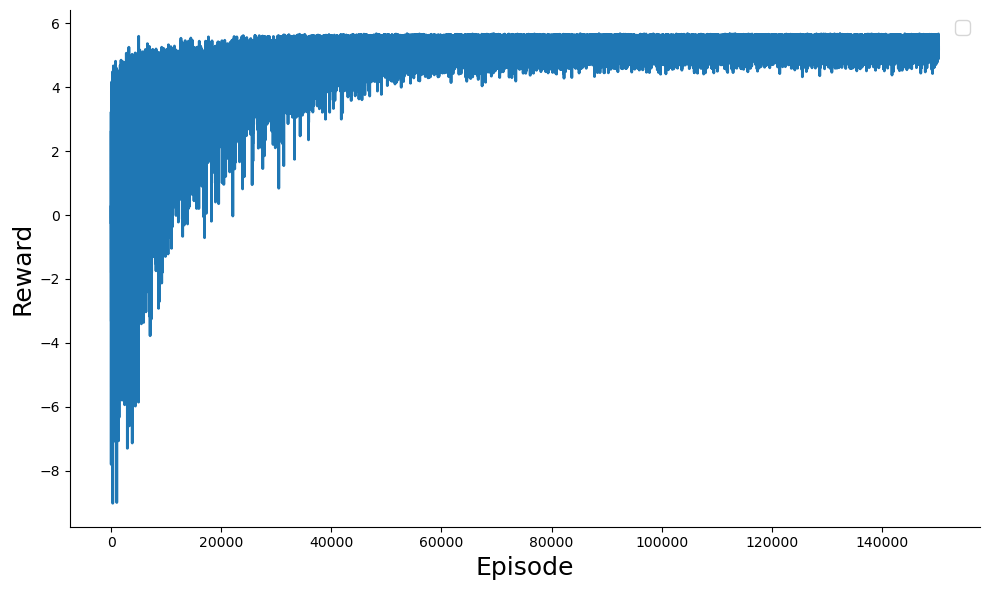

In [10]:
# ==== 3. Plot learning curve ====
plt.figure(figsize=(10, 6))
sns.lineplot(x=range(len(df)), y=df["r"], linewidth=2)

plt.xlabel("Episode", fontsize=18)
plt.ylabel("Reward", fontsize=18)
plt.legend(fontsize=14)
sns.despine()

plt.tight_layout()
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Action taken: [ 1.         -0.41238496  1.          1.        ]
False
First reward: 0.9888546209642554
(1, 660)
Action taken: [-0.36242703 -1.          1.          0.92664117]
Second reward: 1.1203069318027472
Action taken: [ 0.56891465 -0.5959692   1.          1.        ]
Third reward: 1.117437805832722
False


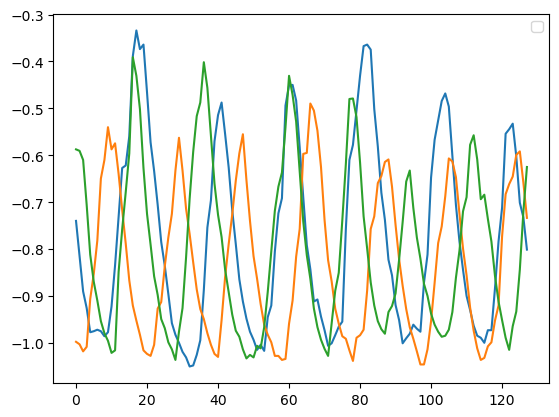

In [11]:
obs, info = env.reset()  # Reset the environment with a specific frequency

action, _states = model.predict(obs, deterministic=True)
action
print("Action taken:", action)
first_params = np.hstack((env.uncertain, action))



# print("First Reward:",jl.reward_normalized_past_amort(first_params, 1/7))
obs, reward, terminated, truncated, info = env.step(action)
print(terminated)

print("First reward:", reward)
print(obs.shape)

# plt.plot(jl.observation_normalized(np.concatenate((env.uncertain, action))), label="Second Design")
plt.legend()
# Take action in the environment

action, _states = model.predict(obs, deterministic=True)

obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Second reward:", reward)

plt.plot(obs[0,0:128], label="First Design")
plt.plot(obs[0,132:260], label="Second Design")

action, _states = model.predict(obs, deterministic=True)

plt.plot(jl.observation(env.uncertain, action), label="Third Design")

obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Third reward:", reward)


print(terminated)




In [15]:
first_rewards = np.zeros(1000)
second_rewards = np.zeros(1000)
third_rewards = np.zeros(1000)
forth_rewards = np.zeros(1000)
fifth_rewards = np.zeros(1000)

# test enviroenment different than training!
env.seed(31415)

for i in range(1000):
    obs, info = env.reset() 
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    first_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    second_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    third_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    forth_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    fifth_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5



first mean:  1.0735789159718325
second mean:  1.0675895945972214
third mean:  1.0695960935239872
forth mean:  1.067355686576841
fifth mean:  1.071617812684073


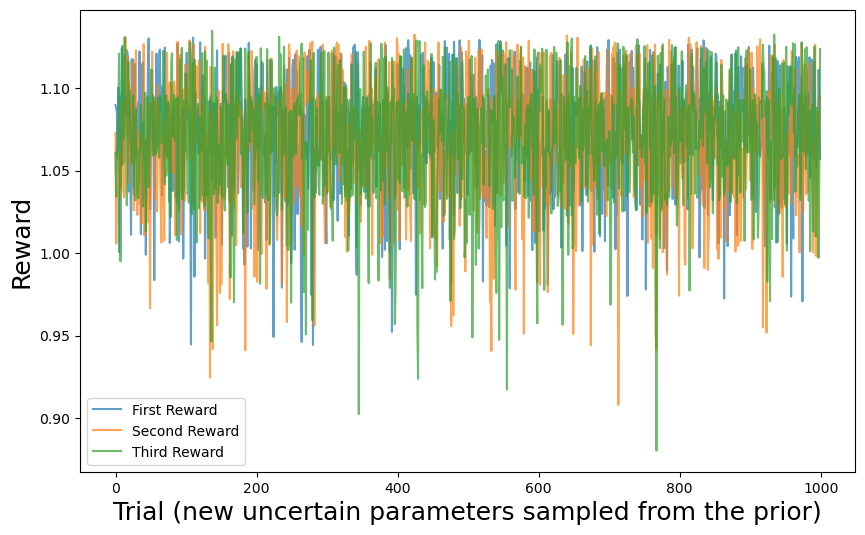

In [22]:

plt.figure(figsize=(10, 6))
plt.plot(first_rewards, label='First Reward', alpha=0.7)
plt.plot(second_rewards, label='Second Reward', alpha=0.7)
plt.plot(third_rewards, label='Third Reward', alpha=0.7)
plt.legend()
plt.xlabel("Trial (new uncertain parameters sampled from the prior)", fontsize=18)
plt.ylabel("Reward", fontsize=18)

print("first mean: ", first_rewards.mean())
print("second mean: ",second_rewards.mean())
print("third mean: ", third_rewards.mean())
print("forth mean: ", forth_rewards.mean())
print("fifth mean: ", fifth_rewards.mean())



Text(0, 0.5, 'Reward')

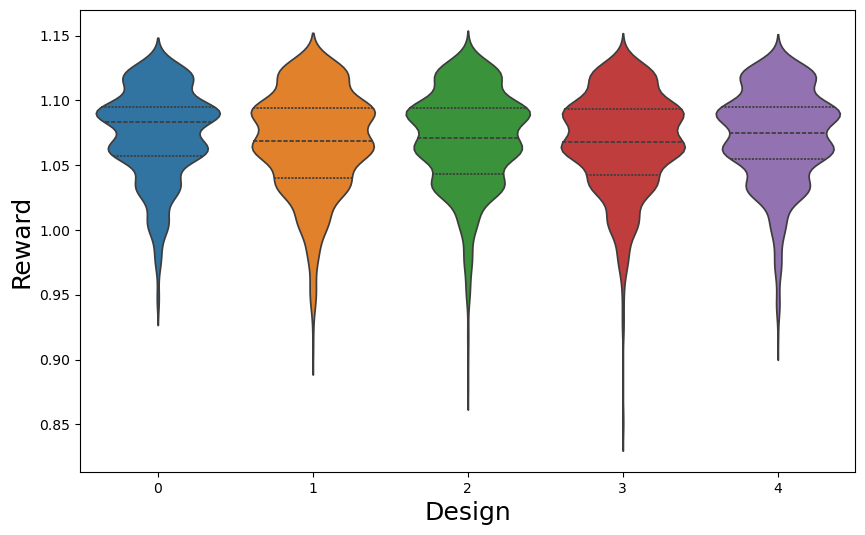

In [17]:
#plot violins seaborn
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.violinplot(data=[first_rewards, second_rewards, third_rewards, forth_rewards, fifth_rewards], inner="quartile")
plt.xlabel("Design", fontsize=18)
plt.ylabel("Reward", fontsize=18)


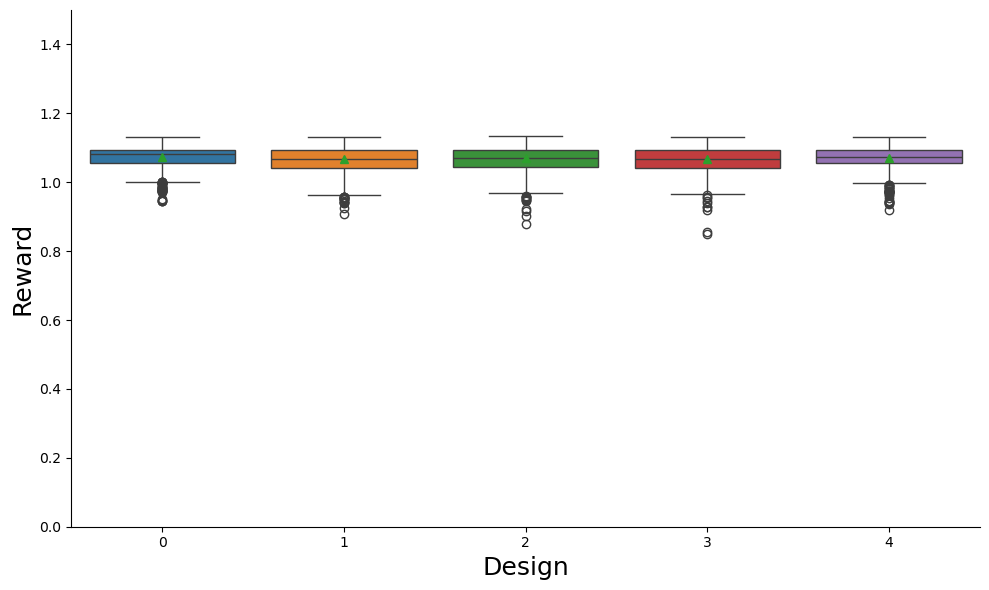

In [23]:
#plot boxplot seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(data=[first_rewards, second_rewards, third_rewards,forth_rewards, fifth_rewards],showmeans=True)
plt.xlabel("Design", fontsize=18)
plt.ylabel("Reward", fontsize=18)
# Set y-axis range
plt.ylim(0, 1.5)
plt.tight_layout()
sns.despine()
plt.savefig("box_0_0_fixed.pdf", format="pdf")



In [17]:
env = Monitor(env, filename=log_dir)

model = PPO.load(model_path, env=env)

model.learn(total_timesteps=500000)


Wrapping the env in a DummyVecEnv.
Logging to logs/rl_repressilator_past_amort_multi_step_frame_5/PPO_3
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 5        |
|    ep_rew_mean     | 5.05     |
| time/              |          |
|    fps             | 20       |
|    iterations      | 1        |
|    time_elapsed    | 97       |
|    total_timesteps | 2048     |
---------------------------------
--------------------------------------
| rollout/                |          |
|    ep_len_mean          | 5        |
|    ep_rew_mean          | 5.11     |
| time/                   |          |
|    fps                  | 18       |
|    iterations           | 2        |
|    time_elapsed         | 217      |
|    total_timesteps      | 4096     |
| train/                  |          |
|    approx_kl            | 1.472285 |
|    clip_fraction        | 0.786    |
|    clip_range           | 0.2      |
|    entropy_loss         | 6.69     |
|    expla

In [18]:
model.save(os.path.join(log_dir, "ppo_model_2"))

In [19]:
import os
import pandas as pd
import seaborn as sns

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

# test environment
env = CustomEnv()

# ==== Configuration ====
log_dir = "logs/rl_repressilator_past_amort_multi_step_frame_5"
model_path = os.path.join(log_dir, "ppo_model_2")
monitor_file = os.path.join(log_dir, "monitor.csv")

df_2 = pd.read_csv(monitor_file, skiprows=1)  # Skip header comment row

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


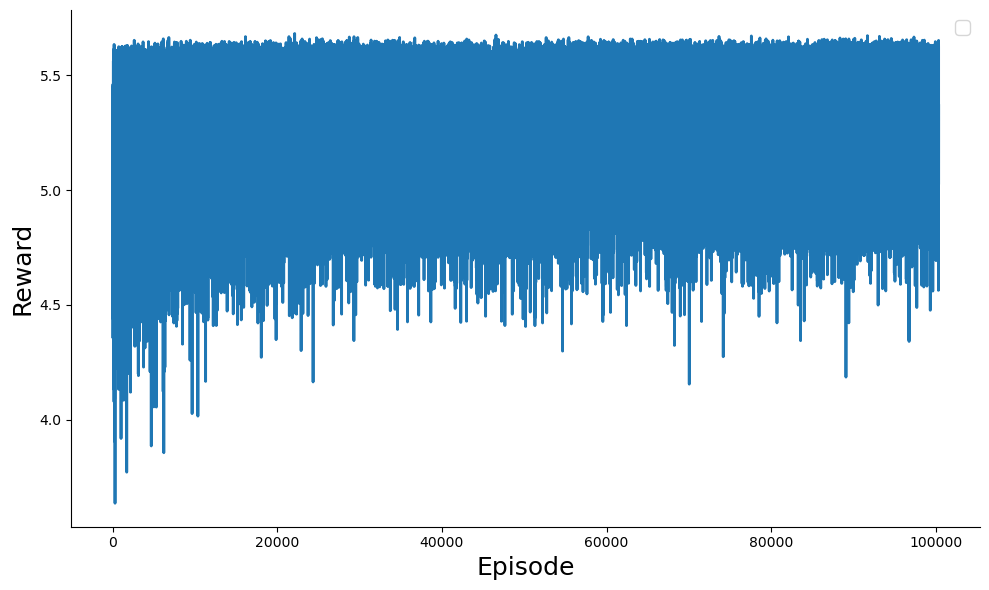

In [20]:
# ==== 3. Plot learning curve ====
plt.figure(figsize=(10, 6))
sns.lineplot(x=range(len(df_2)), y=df_2["r"], linewidth=2)

plt.xlabel("Episode", fontsize=18)
plt.ylabel("Reward", fontsize=18)
plt.legend(fontsize=14)
sns.despine()

plt.tight_layout()
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


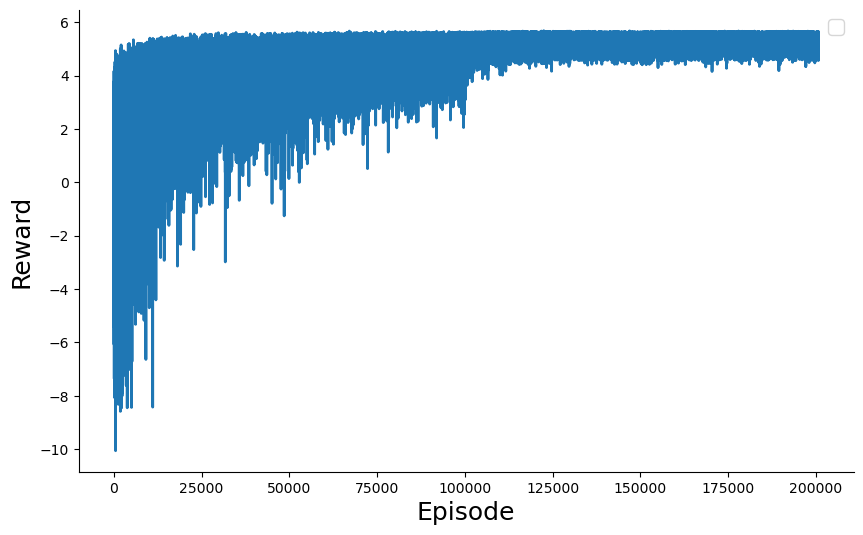

In [21]:
# merge df and df_2

df = pd.concat([df, df_2], ignore_index=True)
plt.figure(figsize=(10, 6))
sns.lineplot(x=range(len(df)), y=df["r"], linewidth=2)
plt.xlabel("Episode", fontsize=18)
plt.ylabel("Reward", fontsize=18)
plt.legend(fontsize=14)
sns.despine()

Text(0, 0.5, 'Reward')

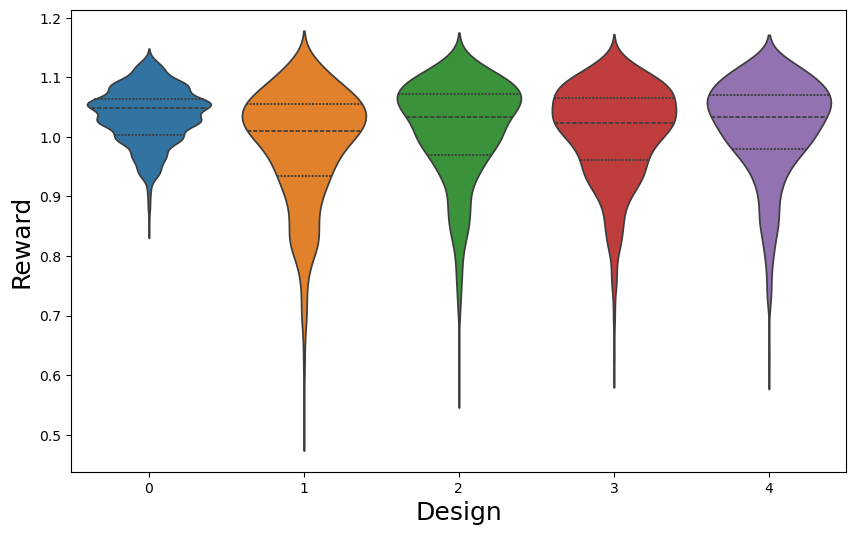

In [23]:
#plot violins seaborn
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.violinplot(data=[first_rewards, second_rewards, third_rewards, forth_rewards, fifth_rewards], inner="quartile")
plt.xlabel("Design", fontsize=18)
plt.ylabel("Reward", fontsize=18)


Text(0, 0.5, 'Reward')

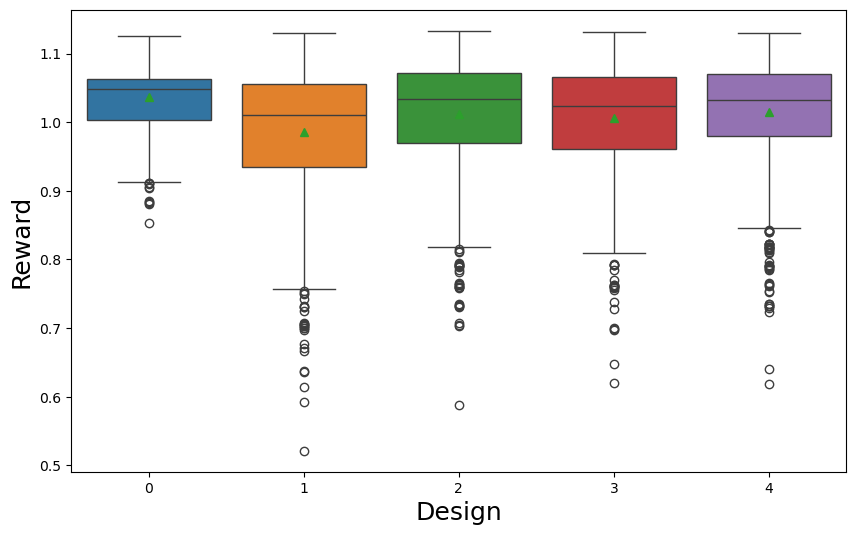

In [24]:
#plot boxplot seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(data=[first_rewards, second_rewards, third_rewards,forth_rewards, fifth_rewards],showmeans=True)
plt.xlabel("Design", fontsize=18)
plt.ylabel("Reward", fontsize=18)

In [105]:
obs, info = env.reset()  # Reset the environment with a specific frequency

action, _states = model.predict(obs, deterministic=True)
action
print("Action taken:", action)
first_params = np.hstack((env.uncertain, action))

first_obs =  jl.plot_amort(np.hstack([env.uncertain, action]))

# print("First Reward:",jl.reward_normalized_past_amort(first_params, 1/7))
obs, reward, terminated, truncated, info = env.step(action)
print(terminated)

print("First reward:", reward)
# Take action in the environment

action, _states = model.predict(obs, deterministic=True)


second_obs =  jl.plot_amort(np.hstack([env.uncertain, action]))

obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Second reward:", reward)
print("Terminated", terminated)

action, _states = model.predict(obs, deterministic=True)

obs, reward, terminated, truncated, info = env.step(action)

third_obs =  jl.plot_amort(np.hstack([env.uncertain, action]))


print("Action taken:", action)
print("Third reward:", reward)
print("Terminated", terminated)

action, _states = model.predict(obs, deterministic=True)

obs, reward, terminated, truncated, info = env.step(action)

forth_obs =  jl.plot_amort(np.hstack([env.uncertain, action]))

print("Action taken:", action)
print("Forth reward:", reward)
print("Terminated", terminated)

action, _states = model.predict(obs, deterministic=True)

fifth_obs = jl.plot_amort(np.hstack([env.uncertain, action]))

obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Fifth reward:", reward)
print("Terminated", terminated)


Action taken: [ 0.8278582 -0.5568037  1.         1.       ]
False
First reward: 0.673587979123082
Action taken: [ 0.46183604 -1.          0.25201946 -0.6121459 ]
Second reward: 1.102091702373994
Terminated False
Action taken: [-0.17290956 -1.          0.9123991   0.05516392]
Third reward: 0.9697459436685637
Terminated False
Action taken: [ 0.83727163 -0.60678923  1.          0.46342283]
Forth reward: 0.9526242128470647
Terminated False
Action taken: [ 1.         -0.34745157  1.          0.77499306]
Fifth reward: 0.9604778935022735
Terminated True


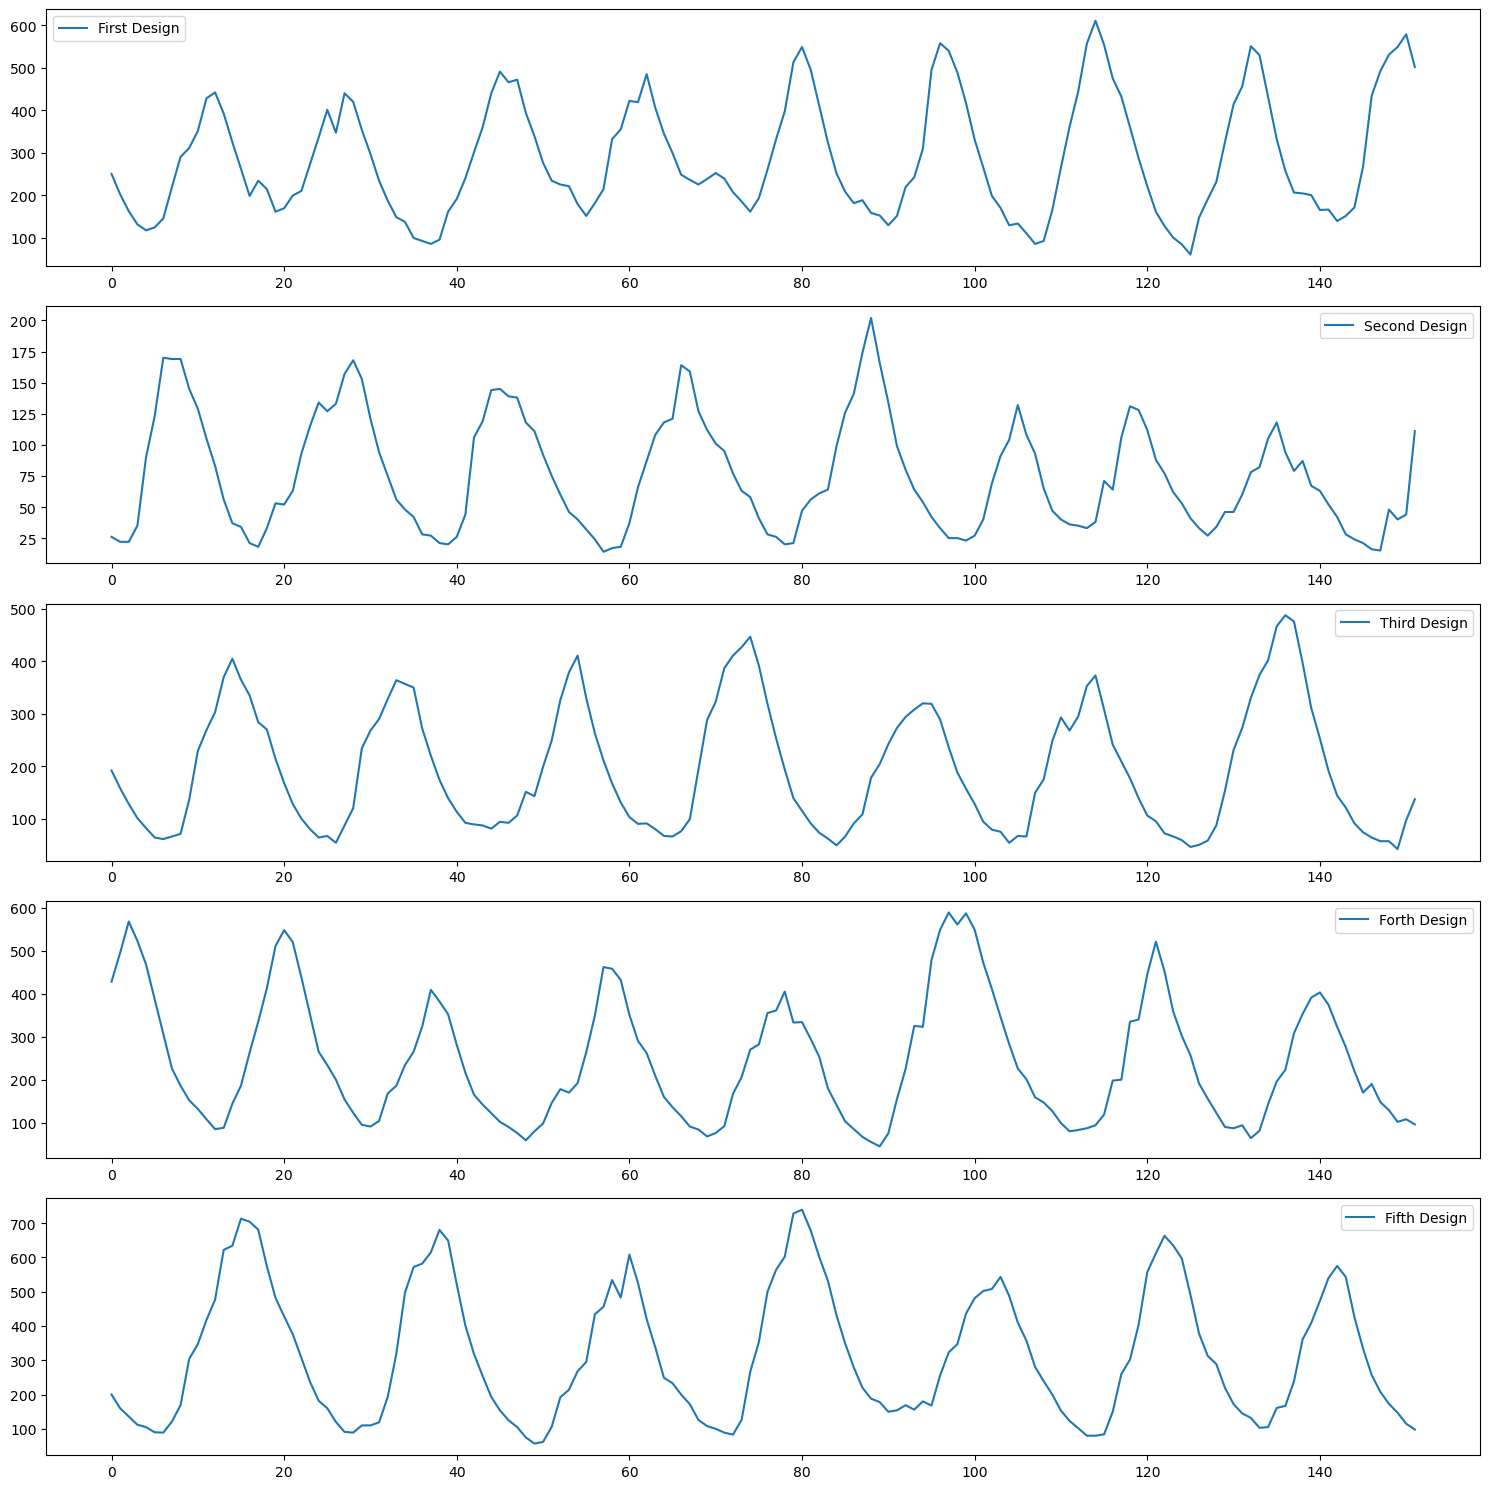

In [108]:
plt.figure(figsize=(15, 15))

plt.subplot(5, 1, 1)
plt.plot(first_obs, label="First Design")
plt.legend()

plt.subplot(5, 1, 2)
plt.plot(second_obs, label="Second Design")
plt.legend()

plt.subplot(5, 1, 3)
plt.plot(third_obs, label="Third Design")
plt.legend()

plt.subplot(5, 1, 4)
plt.plot(forth_obs, label="Forth Design")
plt.legend()

plt.subplot(5, 1, 5)
plt.plot(fifth_obs, label="Fifth Design")
plt.legend()

plt.tight_layout()
plt.show()

In [148]:
import numpy as np
import matplotlib.pyplot as plt

def stacked_amort_heatmap(env, action, step_idx, num_samples=10):
    """
    Repeats jl.plot_amort with the same input multiple times and plots a 2D heatmap.
    
    Parameters:
        env: the environment object
        action: the action taken
        step_idx: index of the current step (for labeling)
        num_samples: number of times to repeat jl.plot_amort
    """
    amort_outputs = []
    for _ in range(num_samples):
        out = jl.plot_amort(np.hstack([env.uncertain, action]))
        amort_outputs.append(out)
    return amort_outputs

# Start interaction with the environment
obs, info = env.reset()
print("Environment reset.")

# Step 1
action, _states = model.predict(obs, deterministic=True)
print("Action taken:", action)
h1 = stacked_amort_heatmap(env, action, step_idx=1)

obs, reward, terminated, truncated, info = env.step(action)
print("Step 1 reward:", reward)
print("Terminated:", terminated)

# Step 2
action, _states = model.predict(obs, deterministic=True)
print("Action taken:", action)
h2 = stacked_amort_heatmap(env, action, step_idx=2)

obs, reward, terminated, truncated, info = env.step(action)
print("Step 2 reward:", reward)
print("Terminated:", terminated)

# Step 3
action, _states = model.predict(obs, deterministic=True)
print("Action taken:", action)
h3 = stacked_amort_heatmap(env, action, step_idx=3)

obs, reward, terminated, truncated, info = env.step(action)
print("Step 3 reward:", reward)
print("Terminated:", terminated)

# Step 4
action, _states = model.predict(obs, deterministic=True)
print("Action taken:", action)
h4 = stacked_amort_heatmap(env, action, step_idx=4)

obs, reward, terminated, truncated, info = env.step(action)
print("Step 4 reward:", reward)
print("Terminated:", terminated)

# Step 5
action, _states = model.predict(obs, deterministic=True)
print("Action taken:", action)
h5 = stacked_amort_heatmap(env, action, step_idx=5)

obs, reward, terminated, truncated, info = env.step(action)
print("Step 5 reward:", reward)
print("Terminated:", terminated)


Environment reset.
Action taken: [ 0.8278582 -0.5568037  1.         1.       ]
Step 1 reward: 0.7023770641335045
Terminated: False
Action taken: [ 0.4359607  -1.          0.8845529  -0.06818658]
Step 2 reward: 1.1363592623186203
Terminated: False
Action taken: [-0.1835736 -1.         0.9515308  1.       ]
Step 3 reward: 0.8535349418147896
Terminated: False
Action taken: [ 0.5770437 -1.         1.         0.3090974]
Step 4 reward: 1.136290171148281
Terminated: False
Action taken: [ 1.        -0.6710212  1.         1.       ]
Step 5 reward: 1.1329427308904387
Terminated: True


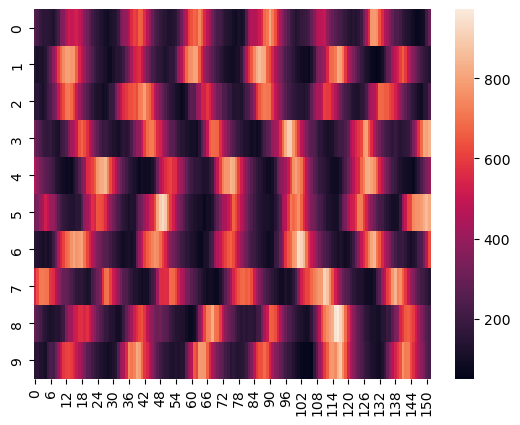

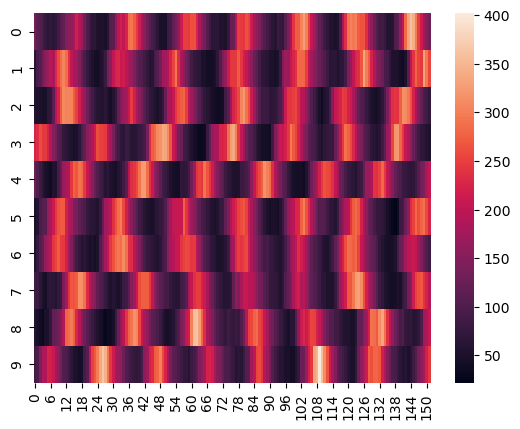

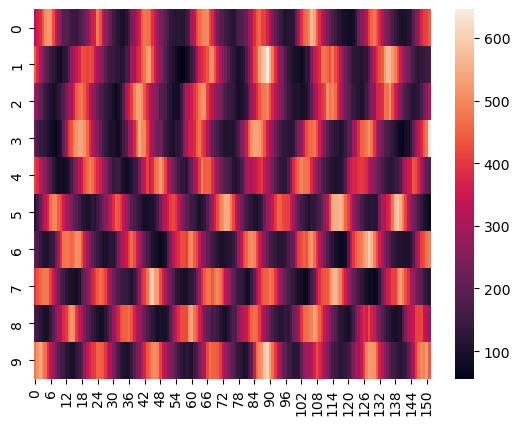

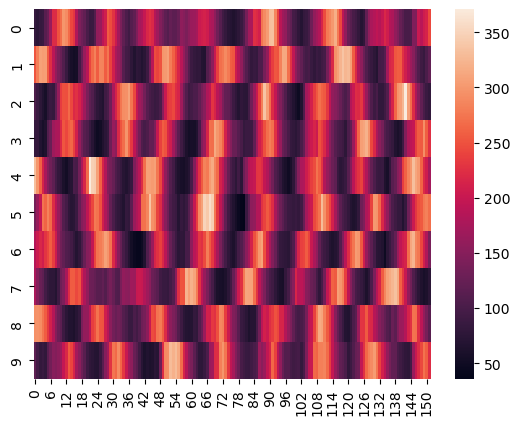

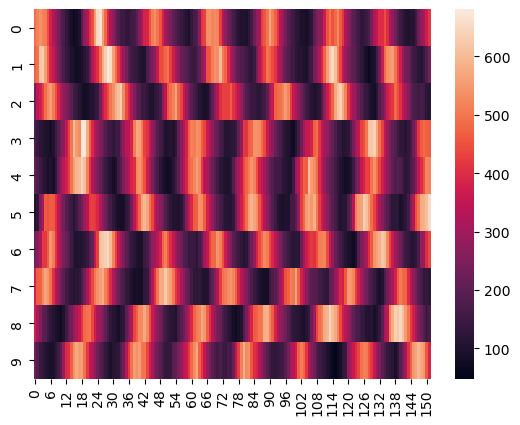

In [149]:
sns.heatmap(h1)
plt.show()
sns.heatmap(h2)
plt.show()
sns.heatmap(h3)
plt.show()
sns.heatmap(h4)
plt.show()
sns.heatmap(h5)
plt.show()

In [64]:
obs, info = env.reset(options={'frequancy': 1/8})  # Reset the environment with a specific frequency
    
# Predict action
action, _states = model.predict(obs, deterministic=True) 
print(action)
jl.reward_amort(action,1/8)
plt.plot(jl.plot_amort(action))

[-0.18644197 -0.9941113   1.          0.6916606 ]


JuliaError: BoundsError: attempt to access 4-element PyArray{Float32, 1} at index [5]
Stacktrace:
 [1] throw_boundserror(A::PyArray{Float32, 1, true, true, Float32}, I::Tuple{Int64})
   @ Base ./essentials.jl:14
 [2] checkbounds
   @ ./abstractarray.jl:699 [inlined]
 [3] pyarray_getindex
   @ ~/.julia/packages/PythonCall/Nr75f/src/Wrap/PyArray.jl:663 [inlined]
 [4] getindex
   @ ~/.julia/packages/PythonCall/Nr75f/src/Wrap/PyArray.jl:659 [inlined]
 [5] unnorm_params(normalized_params::PyArray{Float32, 1, true, true, Float32})
   @ Main ~/Coding/RL-circuits/rl_repressilator_past_amort_setup.jl:59
 [6] reward_amort(normalized_params::PyArray{Float32, 1, true, true, Float32}, desired_freq::Float64)
   @ Main ~/Coding/RL-circuits/rl_repressilator_past_amort_setup.jl:75
 [7] pyjlany_call(self::typeof(reward_amort), args_::Py, kwargs_::Py)
   @ PythonCall.JlWrap ~/.julia/packages/PythonCall/Nr75f/src/JlWrap/any.jl:0
 [8] _pyjl_callmethod(f::Any, self_::Ptr{PythonCall.C.PyObject}, args_::Ptr{P

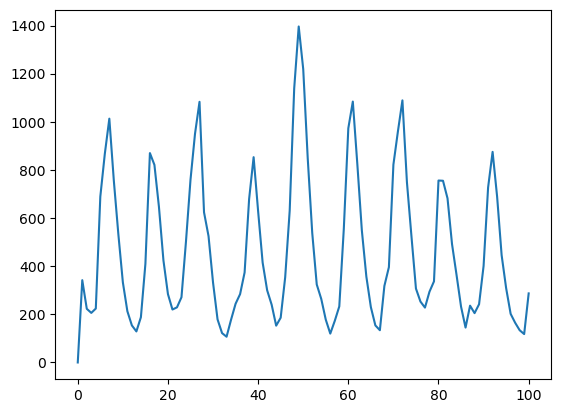

In [193]:

action, _states = model.predict(obs, deterministic=True) 
jl.reward_amort(action,1/10)
plt.plot(jl.plot_amort(action))

[-0.24743213  1.         -0.49190277  1.          1.        ]


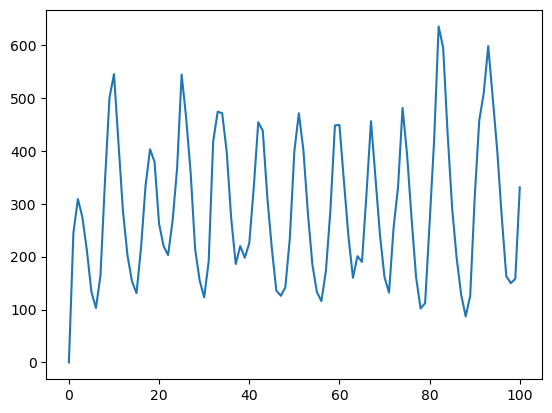

In [12]:
obs, info = env.reset(options={'frequancy': 1/10})  # Reset the environment with a specific frequency
    
# Predict action
action, _states = model.predict(obs, deterministic=True) 
print(action)
jl.reward_amort(action,1/10)
plt.plot(jl.plot_amort(action))

[ 0.9266927  1.        -0.9064123  1.         1.       ]
-0.5484597951722563


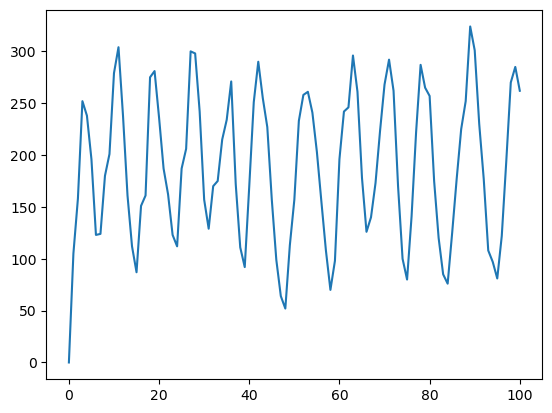

In [63]:
obs, info = env.reset(options={'frequancy': 1/12})  # Reset the environment with a specific frequency
    
# Predict action
action, _states = model.predict(obs, deterministic=True) 
print(action)
print(jl.reward_amort(action,1/12))
plt.plot(jl.plot_amort(action))

In [202]:
rev10 = np.zeros(100)
rev9 = np.zeros(100)
rev11 = np.zeros(100)
for i in range(100):
    obs, info = env.reset(options={'frequancy': 1/10}) 
    env.frequancy = 1/10
        
    # Predict action
    action, _states = model.predict(obs, deterministic=True) 
    rev10[i] = jl.reward_amort(action,1/10)
    rev9[i] = jl.reward_amort(action,1/9)
    rev11[i] = jl.reward_amort(action,1/11)
print(rev10.mean(), rev10.std())
print(rev9.mean(), rev9.std())
print(rev11.mean(), rev11.std())

0.030861651764838762 0.38155695014611873
-0.9489301528593321 0.5099098517389462
-0.7196163637373822 0.40851304991854526


In [203]:
rev8 = np.zeros(100)
rev9 = np.zeros(100)
rev7 = np.zeros(100)
for i in range(100):
    obs, info = env.reset(options={'frequancy': 1/8}) 
    env.frequancy = 1/8
        
    # Predict action
    action, _states = model.predict(obs, deterministic=True) 
    rev8[i] = jl.reward_amort(action,1/8)
    rev9[i] = jl.reward_amort(action,1/9)
    rev7[i] = jl.reward_amort(action,1/7)
print(rev10.mean(), rev8.std())
print(rev9.mean(), rev9.std())
print(rev11.mean(), rev7.std())

0.030861651764838762 0.49172829444986077
-1.5035365016307207 0.8585483345559198
-0.7196163637373822 0.6841481384323931


In [29]:
# Store actions in a list
actions = []

# Generate 1000 samples
for _ in range(100000):
    # Reset env with random hidden_state (as in your example)
    obs, info = env.reset()
    env.frequancy = 1/8
    
    # Predict action
    action, _states = model.predict(obs, deterministic=False)  # deterministic=False for stochastic sampling
    actions.append(jl.denormalize_params(action))

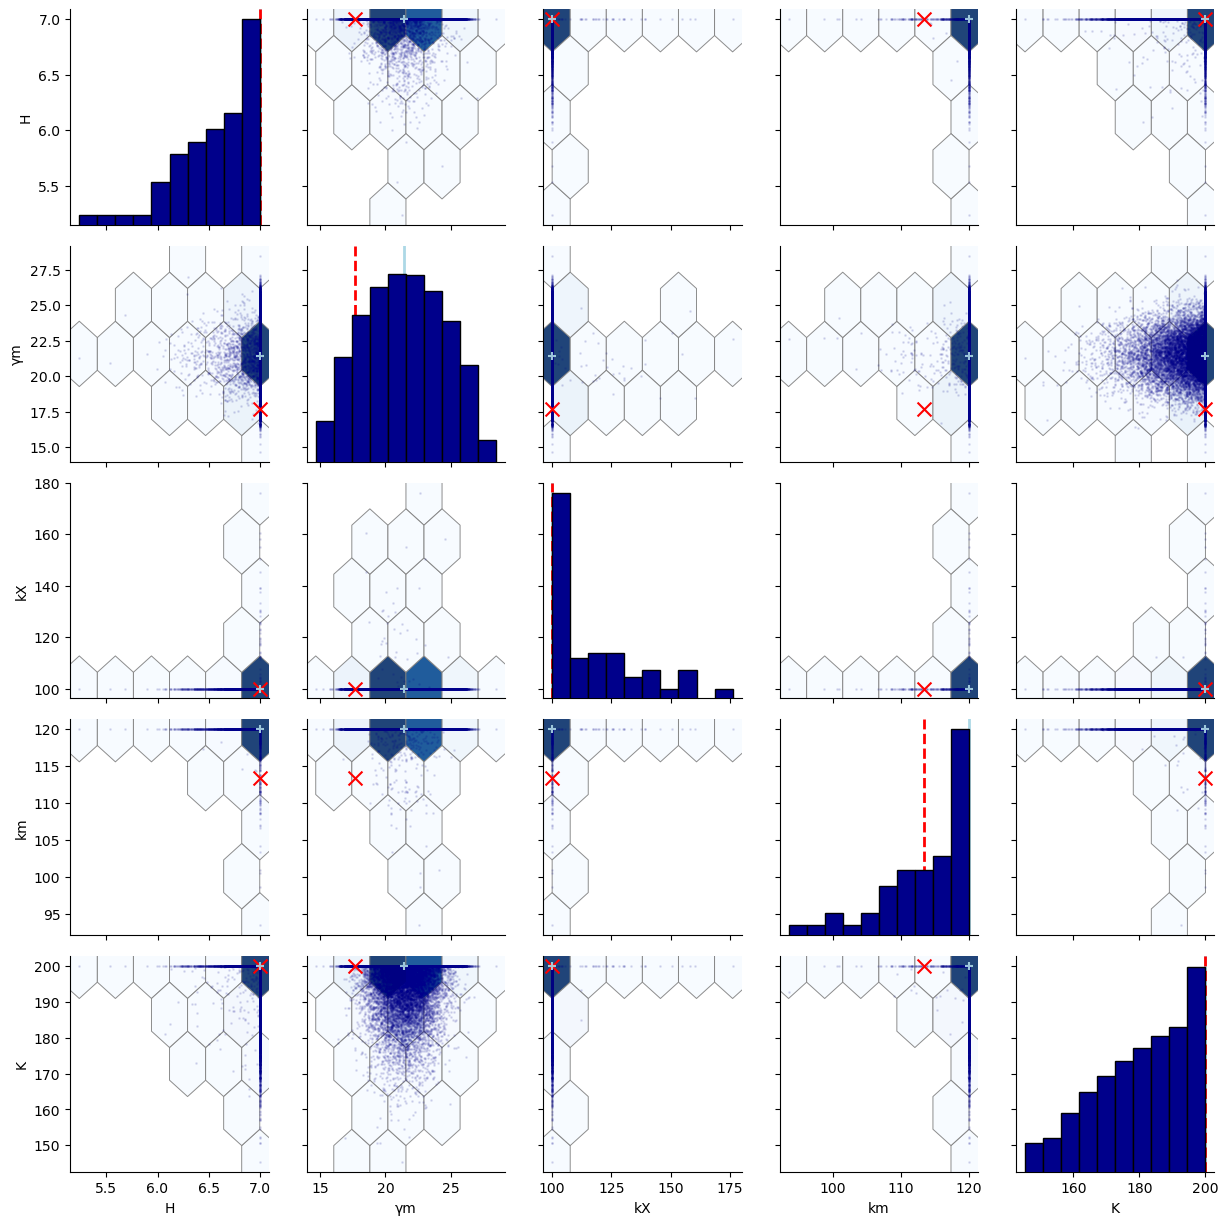

In [50]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create the DataFrame
df = pd.DataFrame(actions, columns=["H", "γm", "kX", "km", "K"])

# Define ground truth and deterministic prediction
gt = [7.0, 17.6822, 100.0, 113.4372, 199.8989]
action_determinstic = model.predict(obs, deterministic=True)[0]
action_determinstic_denormalized = jl.denormalize_params(action_determinstic)

# Hexbin plot function
def hexbin_plot(x, y, color, **kwargs):
    ax = plt.gca()
    ax.hexbin(
        x, y,
        gridsize=5,
        cmap='Blues',
        mincnt=1,
        edgecolors='gray',
        linewidths=0.7,
        alpha=0.9
    )

# Histogram function for diagonal
def hist_plot(x, color, **kwargs):
    ax = plt.gca()
    ax.hist(x, bins=10, color='darkblue', edgecolor='black',log=True)

# Initialize PairGrid
g = sns.PairGrid(df)
g.map_lower(hexbin_plot)
g.map_diag(hist_plot)
g.map_upper(hexbin_plot)

# Overlay scatter points and vertical lines
for row in range(len(df.columns)):
    for col in range(len(df.columns)):
        ax = g.axes[row, col]

        if row == col:
            # Add vertical lines to diagonal
            ax.axvline(action_determinstic_denormalized[row], color='lightblue',zorder=10, linewidth=2, label='Deterministic' if row == 0 else "")
            ax.axvline(gt[row], color='red', linestyle='--', linewidth=2, zorder=10, label='Ground Truth' if row == 0 else "")
        else:
            ax.scatter(df.iloc[:, col], df.iloc[:, row],
                       color='darkblue', s=1, alpha=0.1, label='Samples' if (row, col) == (1, 0) else "")
            ax.scatter(gt[col], gt[row],
                       color='red', s=100,marker='x', label='Ground Truth' if (row, col) == (1, 0) else "")
            ax.scatter(action_determinstic_denormalized[col], action_determinstic_denormalized[row],
                       color='lightblue', marker="+", alpha=0.9, label='Deterministic' if (row, col) == (1, 0) else "")

# Add legend only once
handles, labels = g.axes[-1][0].get_legend_handles_labels()
if handles:
    g.axes[-1][0].legend(handles, labels, loc='upper right', fontsize='small')

plt.show()


In [46]:
stochastic_policy_result = []
for i in range(1000):
    action = model.predict(obs)[0]
    stochastic_policy_result.append(jl.reward(action))

action_determinstic = model.predict(obs, deterministic=True)[0]

policy_det_eval = jl.evaluate_params(action_determinstic)

sequiros_eval = jl.evaluate_params(jl.normalize_params(np.array(gt, dtype=np.float32)))



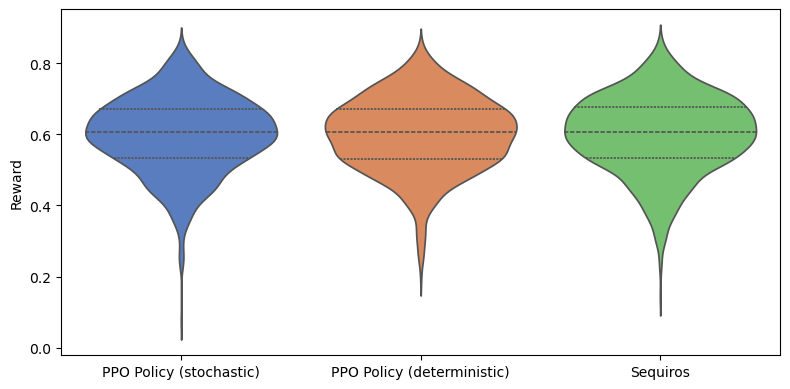

mean of policy_det_eval: 0.5997235608265995
mean of policy_stoch_eval: 0.5988463618449332
mean of sequiros_eval: 0.5999704605703644


In [47]:

plt.figure(figsize=(8, 4))
sns.violinplot(data=[stochastic_policy_result, policy_det_eval, sequiros_eval], inner="quartile", palette="muted")
plt.xticks([0, 1, 2], ['PPO Policy (stochastic)','PPO Policy (deterministic)', 'Sequiros'])
plt.ylabel('Reward')
plt.tight_layout()
plt.show()

print("mean of policy_det_eval:", np.mean(policy_det_eval))
print("mean of policy_stoch_eval:", np.mean(stochastic_policy_result))
print("mean of sequiros_eval:", np.mean(sequiros_eval))